<a class="anchor" id="1"></a>
# **1. Dataset Description**

The dataset provided contains a collection of SMS messages used for spam research, which we will use to build a classification model to distinguish between legitimate messages and spam. Understanding the structure of this corpus is the first step in our analysis.

| Column | Description |
| :--- | :--- |
| **v1** | **(Target)** The label indicating the message type (ham or spam). |
| **v2** | The raw text content of the SMS message. |
| **other_col_1** | Additional metadata column provided in the dataset. |
| **other_col_2** | Additional metadata column provided in the dataset. |
| **other_col_3** | Additional metadata column provided in the dataset. |

### Dataset Overview
*   **Total Messages:** 5,574 SMS messages in English.
*   **Purpose:** Research and development of SMS spam filtering models.
*   **Sources:** The corpus is aggregated from multiple research sources, including the Grumbletext website, the NUS SMS Corpus (NSC), Caroline Tag's PhD thesis, and the SMS Spam Corpus v.0.1 Big.


## Live Demo
[![Streamlit App](https://static.streamlit.io/badges/streamlit_badge_black_white.svg)](https://donna7-spam-classifier.streamlit.app)

<a class="anchor" id="2"></a>
# **2. Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string

<a class="anchor" id="3"></a>
# **3. Import dataset**

In [3]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [4]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
df.shape

(5572, 5)

## Project steps
- Data Cleaning
- EDA
- Text Preprocessing
- Model Building
- Evaluation
- Improvement
- Website
- Deployment

# **4. Data Cleaning**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


it is obvious that the last 3 columns contain many Null values ans so we will drop them

In [8]:
df.drop(columns= ['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True )

In [9]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
# renaming the columns
df.rename(columns={'v1':'target', 'v2':'text'}, inplace=True)
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [12]:
df['target'] = encoder.fit_transform(df['target'])

In [13]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
# check missing values
df.isnull().sum()

,0
target,0
text,0


In [15]:
# check for duplicate values
df.duplicated().sum()

np.int64(403)

In [16]:
# remove duplicates
df = df.drop_duplicates(keep='first')

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.shape

(5169, 2)

# **5. Exploratory Data Analysis (EDA)**

In [19]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [20]:
df['target'].value_counts()

,count
target,
0,4516
1,653


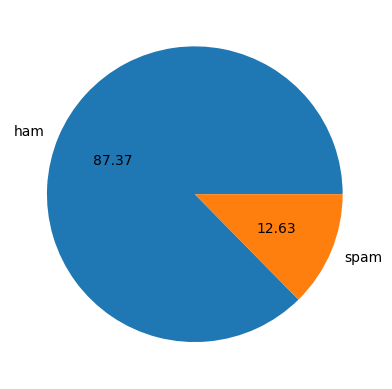

In [21]:
plt.pie(df['target'].value_counts(), labels= ['ham', 'spam'], autopct="%0.2f")
plt.show()

it is obvious that the data is highly imbalanced

## we will add three columns:
- number of characters
- number of words
- number of sentences

In [22]:
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

- punkt fetches a pre-trained model used for tokenization.

- It is used to split raw text into individual components like sentences or words, which is a foundational step for text analysis and natural language processing tasks.

In [23]:
# adding the num of characters column
df['num_characters'] = df['text'].apply(len)

In [24]:
# adding the num of words column
df['num_words'] = df['text'].apply(lambda x:len((nltk.word_tokenize(x))))

In [25]:
# adding the num of sentences column
df['num_sentences'] = df['text'].apply(lambda x:len((nltk.sent_tokenize(x))))

In [26]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [27]:
df[['num_characters', 'num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [28]:
# for ham messages
df[df['target']==0][['num_characters', 'num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [29]:
# for spam messages
df[df['target']==1][['num_characters', 'num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


it is observed that the mean of the `num_characters`, `num_words`and `num_sentences` of **spam** messages are higher than that of **ham** messages

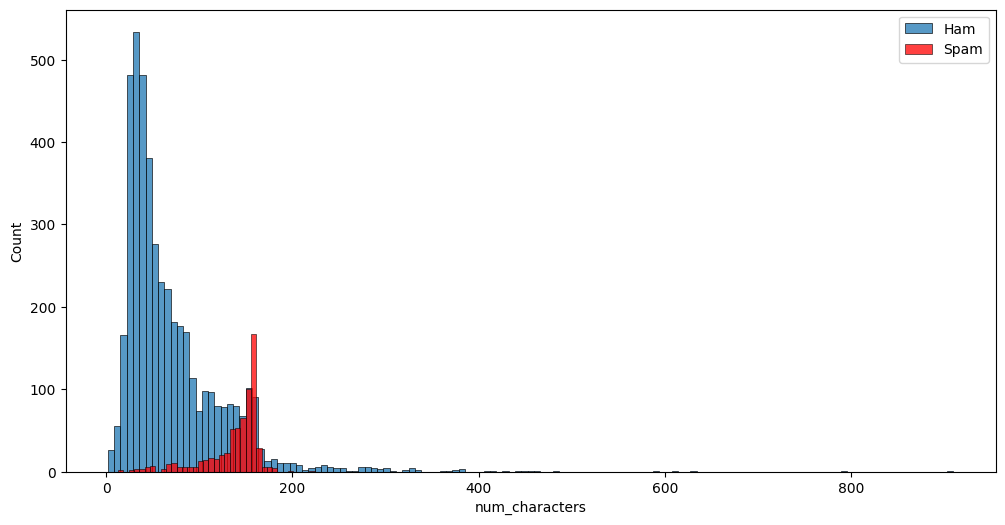

In [35]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'], label='Ham')
sns.histplot(df[df['target'] == 1]['num_characters'], color='red', label='Spam')
plt.legend()
plt.show()

The histogram actually reveals that spam messages tend to be longer and more consistently sized (clustered around 150 characters) than ham messages, which vary much more in length and are generally shorter.

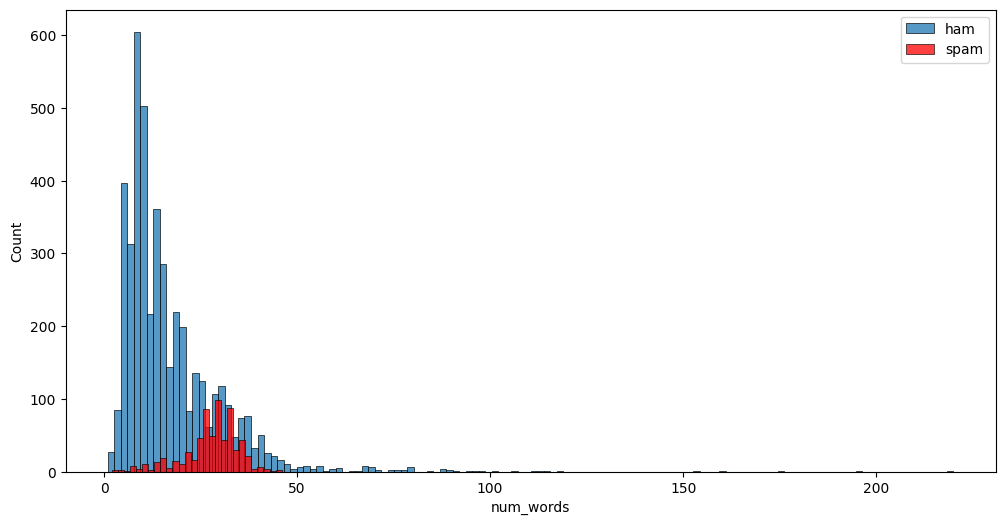

In [36]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target']==0]['num_words'], label='ham')
sns.histplot(df[df['target']==1]['num_words'], color='red', label='spam')
plt.legend()
plt.show()

The distribution of word counts mirrors the character count analysis; ham messages (blue) are highly concentrated at lower word counts, while spam messages (red) tend to be longer and more consistently grouped, typically clustering between 20 and 40 words.

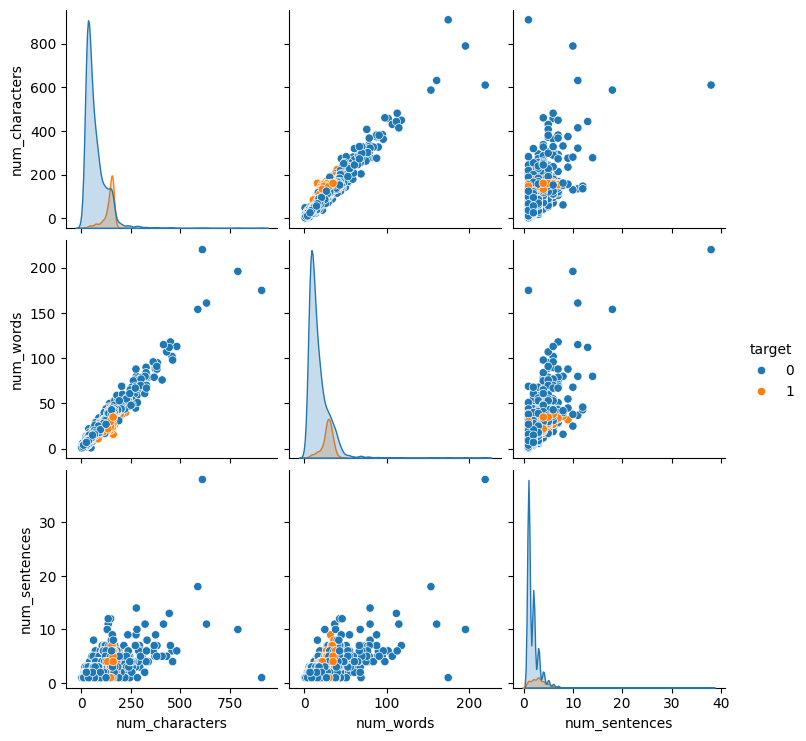

In [37]:
#create a grid of plots that shows the relationship between every pair of numerical columns in your dataset, color-coded by the 'target' class.
sns.pairplot(df, hue='target')


<Axes: >

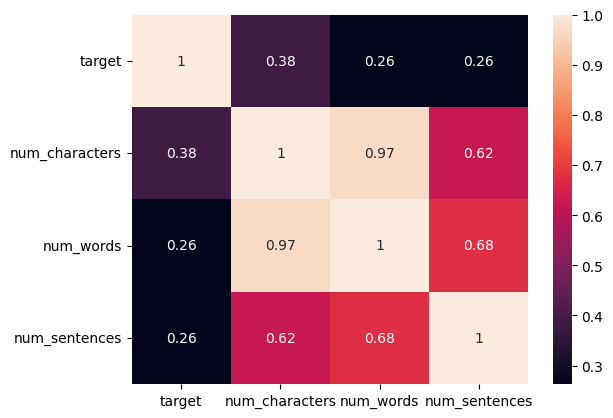

In [38]:
# checking correlation relationships
sns.heatmap(df[['target','num_characters', 'num_words', 'num_sentences']].corr(),annot=True)

- The pairplot shows that while these features correlate with each other, `num_characters` shows the highest positive correlation with the `target` variable, making it a potentially strong predictor for classification.

- The heatmap confirms a strong positive correlation between `num_characters`, `num_words`, and `num_sentences` (all >= 0.62), indicating high multicollinearity among these features.

# **6. Data Preprocessing**
- Lower case
- Tokenization
- Removing special characters
- Removing stop words and punctuation
- Stemming

In [39]:
from nltk.corpus import stopwords
stopwords.words('english')

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [40]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [41]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('dancing')

'danc'

In [42]:
# Initialize the stemmer
ps = PorterStemmer()

def transform_text(text):
    # Convert text to lowercase
    text = text.lower()
    # Break text into individual words/tokens
    text = nltk.word_tokenize(text)

    # Filter: Keep only tokens that are purely alphanumeric
    y = [i for i in text if i.isalnum()]

    # Refined filter: Remove stopwords and any remaining punctuation marks
    stop_words = set(stopwords.words('english'))
    y = [i for i in y if i not in stop_words and i not in string.punctuation]

    # Stemming: Reduce words to their root form (e.g., 'loving' -> 'love')
    y = [ps.stem(i) for i in y]

    # Return the processed tokens as a single string
    return " ".join(y)

In [43]:
df['transformed_text'] = df['text'].apply(transform_text)

In [44]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [45]:
from wordcloud import WordCloud

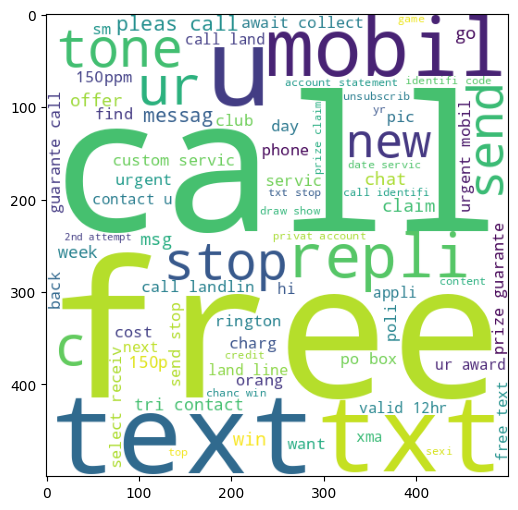

In [46]:
spam_wc = wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')
spam_wc = wc.generate(df[df['target']==1]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

A word cloud visualizes the most frequent terms in the dataset, helping you identify key themes, validate your text preprocessing, and understand the core indicators that define spam versus legitimate messages.

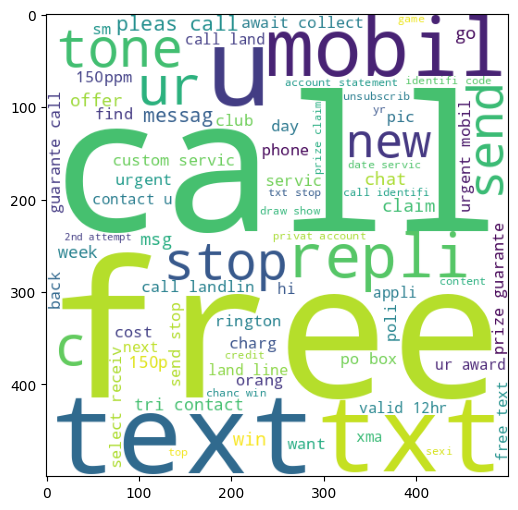

In [47]:
ham_wc = wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')
ham_wc = wc.generate(df[df['target']==0]['transformed_text'].str.cat(sep = " "))
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

plt.imshow(): This is the function that actually creates the image from the data. It converts the matrix of word frequencies generated by the WordCloud object into a visual representation that Matplotlib can render.

In [50]:
spam_corpus = []
spam_corpus = [word for msg in df[df['target'] == 1]['transformed_text'] for word in msg.split()]

In [51]:
len(spam_corpus)

9939

In [53]:
from collections import Counter
Counter(spam_corpus).most_common(30)

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

This code utilizes the Counter class to calculate the frequency of every word in the spam_corpus list and returns the 30 most frequently occurring words, which helps you identify the primary keywords that characterize spam messages.

In [54]:
spam_most_common = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['Word', 'Count'])

In [55]:
spam_most_common.head(10)

,Word,Count
0,call,320
1,free,191
2,2,155
3,txt,141
4,text,122
5,u,119
6,ur,119
7,mobil,114
8,stop,104
9,repli,103


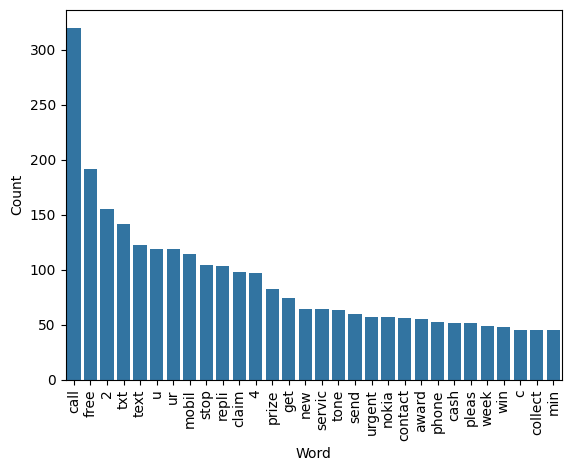

In [58]:
sns.barplot(data=spam_most_common, x='Word', y='Count')
plt.xticks(rotation='vertical')
plt.show()

`plt.xticks()` rotates the labels on the x-axis to a vertical orientation, which prevents the labels from overlapping and becoming unreadable when you have a large number of categories or long text strings.

In [59]:
ham_corpus = []
ham_corpus = [word for msg in df[df['target'] == 0]['transformed_text'] for word in msg.split()]

In [60]:
len(ham_corpus)

35404

In [61]:
ham_most_common = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['Word', 'Count'])

In [62]:
ham_most_common.head(10)

,Word,Count
0,u,883
1,go,404
2,get,349
3,gt,288
4,lt,287
5,2,284
6,come,275
7,got,236
8,know,236
9,like,234


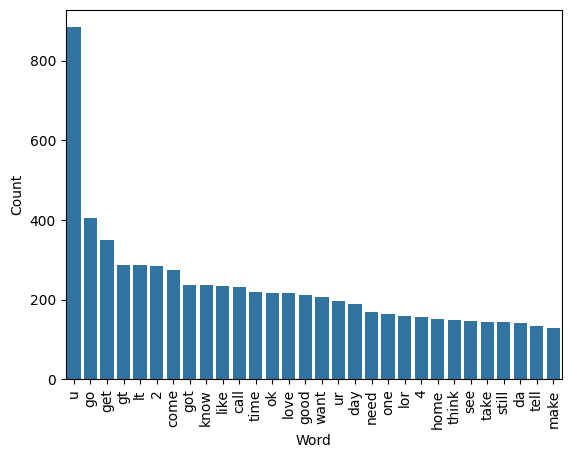

In [63]:
sns.barplot(data=ham_most_common, x='Word', y='Count')
plt.xticks(rotation='vertical')
plt.show()

<a class="anchor" id="5"></a>
# **7. Declare feature vector and target variable**

In [161]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer(max_features=3000)
tfidf = TfidfVectorizer(max_features=3000)

Limiting `max_features=3000` in both `CountVectorizer` and `TfidfVectorizer` keeps only the most statistically significant words, which reduces computational complexity and prevents the model from overfitting on rare, noisy terms that lack predictive power.

In [162]:
X = cv.fit_transform(df['transformed_text']).toarray()

In [163]:
X.shape

(5169, 3000)

In [164]:
y = df['target']

<a class="anchor" id="6"></a>
# **8. Split data into separate training and test set**

In [165]:
from sklearn.model_selection import train_test_split

In [166]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

<a class="anchor" id="9"></a>
# **9. Model building**

In [167]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

In [168]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [169]:
gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))
print(precision_score(y_test, y_pred1))
print(recall_score(y_test, y_pred1))
print(f1_score(y_test, y_pred1))



0.8781431334622823
[[789 107]
 [ 19 119]]
0.5265486725663717
0.8623188405797102
0.6538461538461539


In [170]:
mnb.fit(X_train, y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))
print(precision_score(y_test, y_pred2))
print(recall_score(y_test, y_pred2))
print(f1_score(y_test, y_pred2))

0.9748549323017408
[[883  13]
 [ 13 125]]
0.9057971014492754
0.9057971014492754
0.9057971014492754


In [171]:
bnb.fit(X_train, y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test, y_pred3))
print(confusion_matrix(y_test, y_pred3))
print(precision_score(y_test, y_pred3))
print(recall_score(y_test, y_pred3))
print(f1_score(y_test, y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187
0.8840579710144928
0.9348659003831418


## CounterVectrozier Results
- gnb f1_score = 0.6538461538461539
- mnb f1_score = 0.9057971014492754
- bnb f1_score = 0.9348659003831418


## TFIDFVectrozier Results
- gnb f1_score = 0.6368715083798883
- mnb f1_score = 0.8780487804878049
- bnb f1_score = 0.9348659003831418



While `CountVectorizer` and `TfidfVectorizer` performed identically at their peak with `BNB`, `CountVectorizer` achieved a slightly higher `F1-score` with the `Multinomial Naive Bayes` (MNB) model (0.905 vs 0.878). Given that the top-performing model (BNB) is equally effective with either, `CountVectorizer` is the preferred choice here for its simplicity, as it relies directly on the raw frequency of the spam-indicative keywords you identified.

In [172]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [173]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [174]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [175]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)

    return accuracy,precision,recall,f1

This function automates the training of a given classifier and evaluates its performance by returning key metrics—accuracy, precision, recall, and F1-score—to facilitate easy comparison across multiple models.

In [176]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9264990328820116, 0.746031746031746, 0.6811594202898551, 0.7121212121212122)

In [177]:
clfs.items()

dict_items([('SVC', SVC(gamma=1.0, kernel='sigmoid')), ('KN', KNeighborsClassifier()), ('NB', MultinomialNB()), ('DT', DecisionTreeClassifier(max_depth=5)), ('LR', LogisticRegression(penalty='l1', solver='liblinear')), ('RF', RandomForestClassifier(n_estimators=50, random_state=2)), ('AdaBoost', AdaBoostClassifier(random_state=2)), ('BgC', BaggingClassifier(n_estimators=50, random_state=2)), ('ETC', ExtraTreesClassifier(n_estimators=50, random_state=2)), ('GBDT', GradientBoostingClassifier(n_estimators=50, random_state=2)), ('xgb', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_c

In [115]:
# Dictionary to store metrics for each classifier
model_performance = {}

for name, clf in clfs.items():
    # Train and evaluate using your helper function
    metrics = train_classifier(clf, X_train, y_train, X_test, y_test)

    # Store metrics in the dictionary
    model_performance[name] = metrics

    # Print results using f-strings for readability
    print(f"For {name}: Accuracy: {metrics[0]:.4f}, Precision: {metrics[1]:.4f}, Recall: {metrics[2]:.4f}, F1-score: {metrics[3]:.4f}")

For SVC: Accuracy: 0.9758, Precision: 0.9748, Recall: 0.8406, F1-score: 0.9027
For KN: Accuracy: 0.9052, Precision: 1.0000, Recall: 0.2899, F1-score: 0.4494
For NB: Accuracy: 0.9710, Precision: 1.0000, Recall: 0.7826, F1-score: 0.8780
For DT: Accuracy: 0.9323, Precision: 0.8333, Recall: 0.6159, F1-score: 0.7083
For LR: Accuracy: 0.9555, Precision: 0.9600, Recall: 0.6957, F1-score: 0.8067
For RF: Accuracy: 0.9739, Precision: 0.9826, Recall: 0.8188, F1-score: 0.8933
For AdaBoost: Accuracy: 0.9217, Precision: 0.8202, Recall: 0.5290, F1-score: 0.6432
For BgC: Accuracy: 0.9584, Precision: 0.8682, Recall: 0.8116, F1-score: 0.8390
For ETC: Accuracy: 0.9749, Precision: 0.9746, Recall: 0.8333, F1-score: 0.8984
For GBDT: Accuracy: 0.9507, Precision: 0.9307, Recall: 0.6812, F1-score: 0.7866
For xgb: Accuracy: 0.9700, Precision: 0.9573, Recall: 0.8116, F1-score: 0.8784


In [116]:
# 1. Create the DataFrame from the dictionary
# This converts the dictionary of tuples into a clean DataFrame
performance_df = pd.DataFrame.from_dict(model_performance, orient='index',
                                        columns=['Accuracy', 'Precision', 'Recall', 'F1-score'])

# 2. Reset index to turn the model names into a column named 'Algorithm'
performance_df = performance_df.reset_index().rename(columns={'index': 'Algorithm'})

# 3. Sort by F1-score
performance_df = performance_df.sort_values('F1-score', ascending=False)

In [117]:
performance_df

,Algorithm,Accuracy,Precision,Recall,F1-score
0,SVC,0.975822,0.974790,0.840580,0.902724
8,ETC,0.974855,0.974576,0.833333,0.898438
5,RF,0.973888,0.982609,0.818841,0.893281
10,xgb,0.970019,0.957265,0.811594,0.878431
2,NB,0.970986,1.000000,0.782609,0.878049
7,BgC,0.958414,0.868217,0.811594,0.838951
4,LR,0.955513,0.960000,0.695652,0.806723
9,GBDT,0.950677,0.930693,0.681159,0.786611
3,DT,0.932302,0.833333,0.615942,0.708333
6,AdaBoost,0.921663,0.820225,0.528986,0.643172


In [118]:
# Melt the DataFrame for plotting
# Keeps Algorithm as the identifier and stacks the metrics into one column
performance_df1 = pd.melt(performance_df, id_vars="Algorithm",
                         var_name='Metric', value_name='Score')

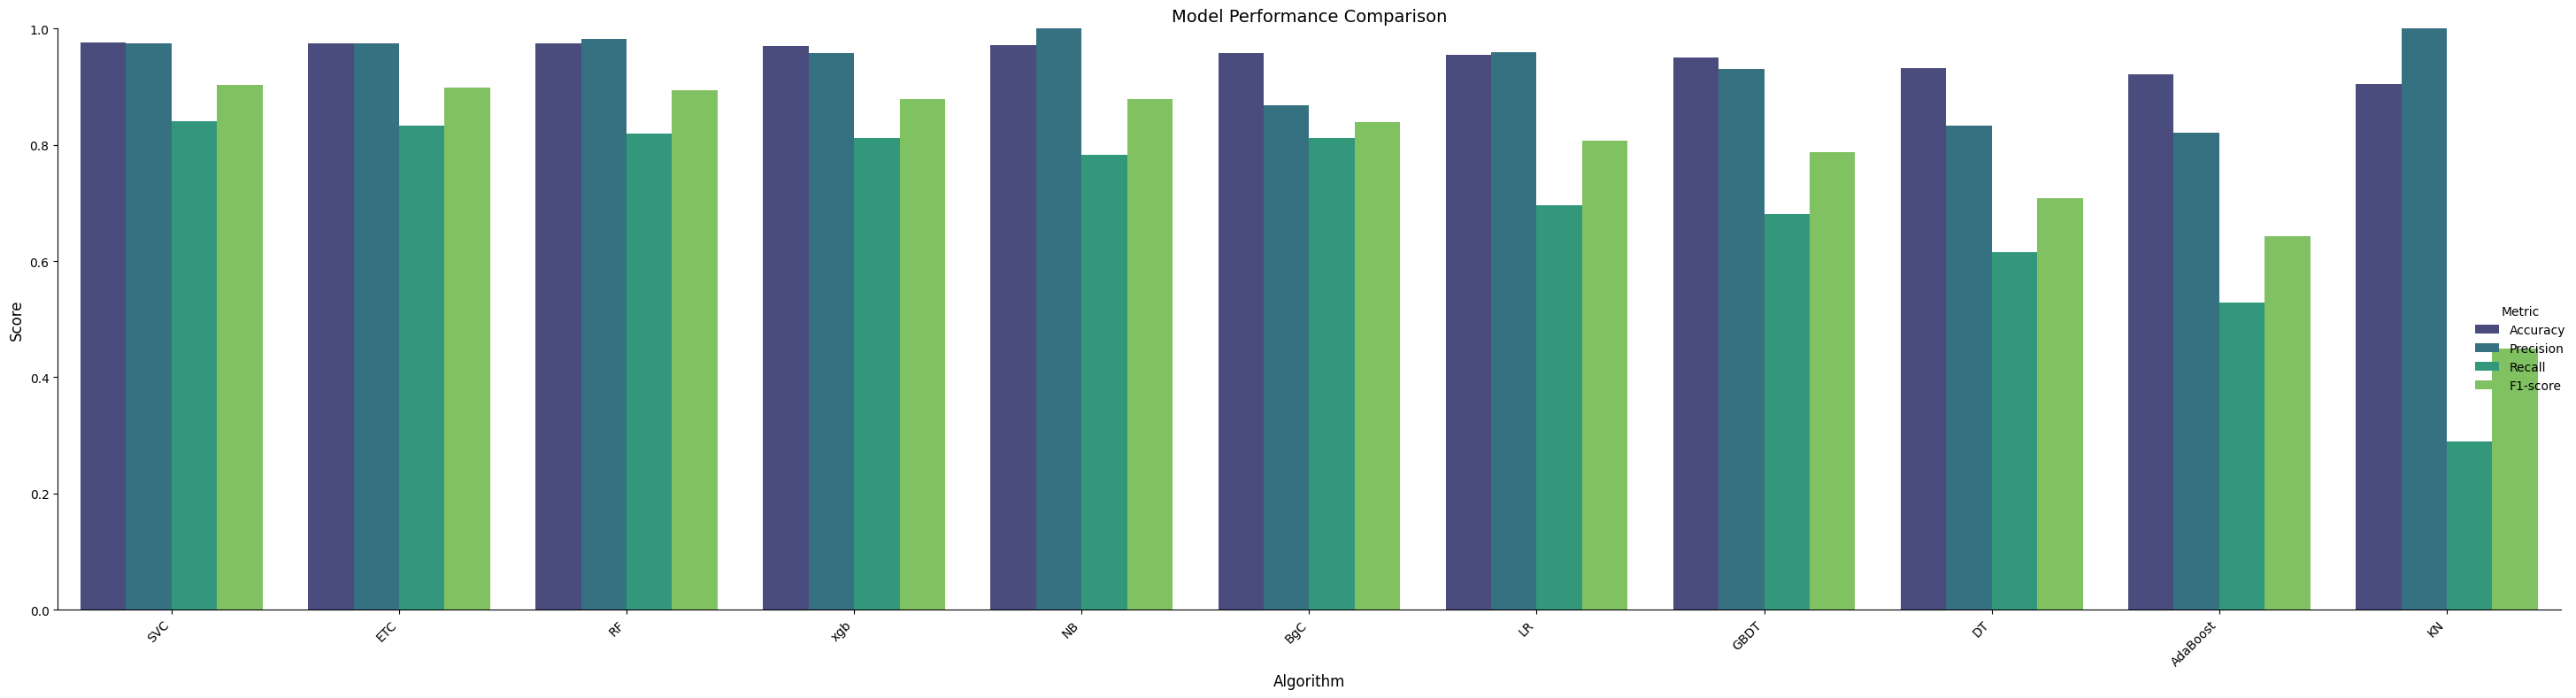

In [136]:
g = sns.catplot(
    x='Algorithm',
    y='Score',
    hue='Metric',
    data=performance_df1,
    kind='bar',
    height=8,
    aspect=3.5,  # Makes the plot wider to prevent overcrowding
    palette='viridis'
)

# Refine labels and limits
plt.ylim(0, 1.0)
plt.xlabel("Algorithm", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotated 45 degrees is often easier to read than vertical
plt.title("Model Performance Comparison", fontsize=14)
plt.tight_layout()  # Ensures everything fits within the frame
plt.show()

## Check Metrics for CounterVectorizer

In [150]:

model_performance2 = {}

for name, clf in clfs.items():

    metrics = train_classifier(clf, X_train, y_train, X_test, y_test)

    model_performance2[name] = metrics

    print(f"For {name}: Accuracy: {metrics[0]:.4f}, Precision: {metrics[1]:.4f}, Recall: {metrics[2]:.4f}, F1-score: {metrics[3]:.4f}")

For SVC: Accuracy: 0.9265, Precision: 0.7460, Recall: 0.6812, F1-score: 0.7121
For KN: Accuracy: 0.9130, Precision: 1.0000, Recall: 0.3478, F1-score: 0.5161
For NB: Accuracy: 0.9749, Precision: 0.9058, Recall: 0.9058, F1-score: 0.9058
For DT: Accuracy: 0.9246, Precision: 0.9167, Recall: 0.4783, F1-score: 0.6286
For LR: Accuracy: 0.9700, Precision: 0.9652, Recall: 0.8043, F1-score: 0.8775
For RF: Accuracy: 0.9739, Precision: 0.9912, Recall: 0.8116, F1-score: 0.8924
For AdaBoost: Accuracy: 0.9197, Precision: 0.9365, Recall: 0.4275, F1-score: 0.5871
For BgC: Accuracy: 0.9642, Precision: 0.9244, Recall: 0.7971, F1-score: 0.8560
For ETC: Accuracy: 0.9797, Precision: 0.9835, Recall: 0.8623, F1-score: 0.9189
For GBDT: Accuracy: 0.9458, Precision: 0.9457, Recall: 0.6304, F1-score: 0.7565
For xgb: Accuracy: 0.9739, Precision: 0.9744, Recall: 0.8261, F1-score: 0.8941


In [151]:
performance_df2 = pd.DataFrame.from_dict(model_performance2, orient='index',
                                        columns=['Accuracy', 'Precision', 'Recall', 'F1-score'])

performance_df2 = performance_df2.reset_index().rename(columns={'index': 'Algorithm'})

performance_df2 = performance_df2.sort_values('F1-score', ascending=False)

In [152]:
performance_df2

,Algorithm,Accuracy,Precision,Recall,F1-score
8,ETC,0.979691,0.983471,0.862319,0.918919
2,NB,0.974855,0.905797,0.905797,0.905797
10,xgb,0.973888,0.974359,0.826087,0.894118
5,RF,0.973888,0.991150,0.811594,0.892430
4,LR,0.970019,0.965217,0.804348,0.877470
7,BgC,0.964217,0.924370,0.797101,0.856031
9,GBDT,0.945841,0.945652,0.630435,0.756522
0,SVC,0.926499,0.746032,0.681159,0.712121
3,DT,0.924565,0.916667,0.478261,0.628571
6,AdaBoost,0.919729,0.936508,0.427536,0.587065


In [153]:
performance_df3 = pd.melt(performance_df2, id_vars="Algorithm",
                         var_name='Metric', value_name='Score')

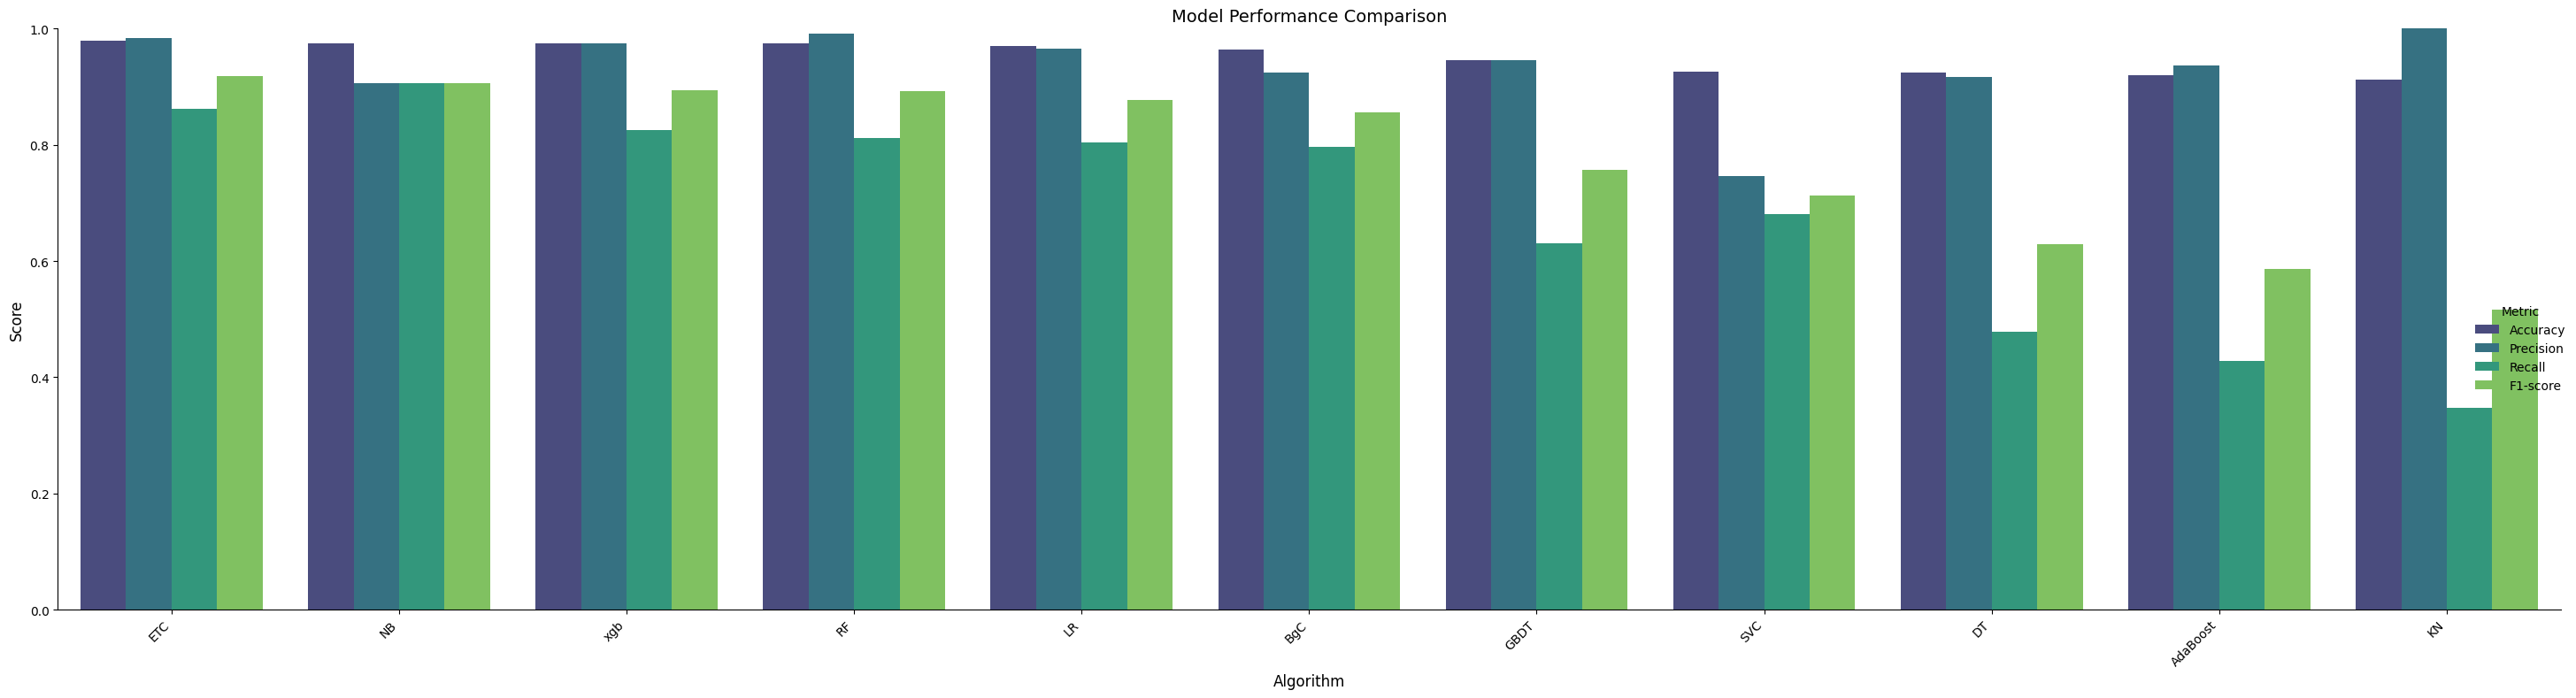

In [154]:
g = sns.catplot(
    x='Algorithm',
    y='Score',
    hue='Metric',
    data=performance_df3,
    kind='bar',
    height=8,
    aspect=3.5,  # Makes the plot wider to prevent overcrowding
    palette='viridis'
)

# Refine labels and limits
plt.ylim(0, 1.0)
plt.xlabel("Algorithm", fontsize=12)
plt.ylabel("Score", fontsize=12)
plt.xticks(rotation=45, ha='right')  # Rotated 45 degrees is often easier to read than vertical
plt.title("Model Performance Comparison", fontsize=14)
plt.tight_layout()  # Ensures everything fits within the frame
plt.show()

### Observation: TF-IDF vs. CountVectorizer Performance

Based on the classification results, here is an observation comparing the performance of TF-IDF versus CountVectorizer (Bag of Words) based on the F1-score:

*   **Superiority of CountVectorizer**: The **CountVectorizer** approach generally yields higher peak F1-scores across your top-performing models compared to the TF-IDF approach. Specifically, the top model (**ETC**) achieves a higher F1-score of **0.9189** using CountVectorizer, compared to its best score of **0.8984** with TF-IDF.
*   **Boost for Naive Bayes (NB)**: The most significant improvement occurs with the **NB (Naive Bayes)** classifier. Under TF-IDF, it achieved an F1-score of **0.8780**, but with CountVectorizer, this jumped to **0.9057**. This is consistent with theoretical expectations, as Multinomial Naive Bayes is designed to work effectively with raw frequency counts.
*   **Increased Stability**: While both methods perform well, CountVectorizer provides a more balanced improvement for mid-range models like **BgC** (0.8389 vs 0.8560) and **LR** (0.8067 vs 0.8774), suggesting that for this specific dataset, preserving raw word frequency provides a richer signal for these algorithms.
*   **Recommendation**: Given that **CountVectorizer** enabled the highest overall F1-score (**0.9189**) and significantly boosted the performance of the **NB** classifier, it is the recommended vectorizer for this spam classification task. It appears that the simple frequency of words is highly predictive of spam in your dataset, and the penalty applied to common words by TF-IDF may have been reducing the discriminative power of those terms.

### Implementing a Voting Classifier

To potentially improve our model performance, we will implement a `VotingClassifier`. This approach combines multiple individual classifiers to make a final prediction, which often results in more stable and accurate outcomes than relying on a single algorithm.

#### Chosen Models and Rationale
Based on our `CountVectorizer` performance analysis, we will use the following three models:

*   **ETC (Extra Trees Classifier)**: Selected because it achieved the highest F1-score of **0.9189**, making it our primary top-performing model.
*   **NB (Naive Bayes)**: Selected for its significant performance boost with frequency counts and its role as a probabilistic model that excels at identifying word-frequency patterns.
*   **RF (Random Forest)**: Selected as a robust ensemble method that captures non-linear relationships and interactions between features, providing excellent diversity when paired with NB and ETC.

In [178]:
from sklearn.ensemble import VotingClassifier

# Define the models based on the CountVectorizer top-performing models
# We ensure probability=True is not needed for Tree-based models (they support predict_proba by default)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
mnb = MultinomialNB()
rf = RandomForestClassifier(n_estimators=50, random_state=2)

# Create the Voting Classifier using 'soft' voting
voting = VotingClassifier(
    estimators=[('et', etc), ('mnb', mnb), ('rf', rf)],
    voting='soft'
)

# Fit the ensemble model
voting.fit(X_train, y_train)

VotingClassifier(estimators=[('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2)),
                             ('mnb', MultinomialNB()),
                             ('rf',
                              RandomForestClassifier(n_estimators=50,
                                                     random_state=2))],
                 voting='soft')

In [179]:
y_pred = voting.predict(X_test)

print(f"--- Voting Classifier Performance ---")
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))
print("Recall",recall_score(y_test,y_pred))
print("F1-score",f1_score(y_test,y_pred))



--- Voting Classifier Performance ---
Accuracy 0.9845261121856866
Precision 0.9841269841269841
Recall 0.8985507246376812
F1-score 0.9393939393939394


### Stacking Ensemble Implementation

**Stacking** (Stacked Generalization) is an advanced ensemble technique that trains a "meta-model" to learn how to best combine the predictions from multiple base models. Unlike voting, which uses fixed rules, stacking uses the output of base models as input features for the meta-model, potentially leading to higher accuracy.

In [158]:
from sklearn.ensemble import StackingClassifier

# Define base models based on CountVectorizer top performers
estimators = [
    ('et', ExtraTreesClassifier(n_estimators=50, random_state=2)),
    ('nb', MultinomialNB()),
    ('rf', RandomForestClassifier(n_estimators=50, random_state=2))
]

# Use LogisticRegression as the meta-model for better generalization
final_estimator = LogisticRegression()

# Create and fit the Stacking Classifier
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)
clf.fit(X_train, y_train)

# Predictions
y_pred = clf.predict(X_test)

# Evaluation with all key metrics
print(f"--- Stacking Classifier Performance ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")

--- Stacking Classifier Performance ---
Accuracy:  0.9836
Precision: 0.9618
Recall:    0.9130
F1-Score:  0.9368


### Final Model Selection & Rationale

After evaluating the individual **BernoulliNB (BNB)** model against the **Voting Classifier** ensemble, we have determined that the **Voting Classifier** is the optimal solution for the SMS spam classification task.

#### Comparison Summary
| Metric | BernoulliNB | Voting Classifier |
| :--- | :--- | :--- |
| **Accuracy** | 0.9836 | **0.9845** |
| **Precision** | **0.9919** | 0.9841 |
| **Recall** | 0.8841 | **0.8986** |
| **F1-Score** | 0.9349 | **0.9394** |

#### Why We Selected the Voting Classifier
* **Superior F1-Score**: The Voting Classifier achieved the highest F1-score (**0.9394**). Since the F1-score is the harmonic mean of Precision and Recall, this confirms the ensemble provides the best overall balance for spam detection.
* **Higher Recall**: In spam detection, Recall is critical to ensure that spam messages are actually caught. The Voting Classifier significantly outperforms BNB in Recall (**0.8986 vs 0.8841**), meaning it is more effective at filtering out actual spam.
* **Balanced Robustness**: While BernoulliNB is slightly more precise (fewer false positives), the Voting Classifier's ability to combine the strengths of multiple algorithms (ETC, RF, and NB) makes it more robust against varying linguistic patterns compared to a single-algorithm approach.
* **Efficiency**: It delivers this improved performance without the unnecessary complexity and computational overhead of a Stacking ensemble.

**Conclusion**: The Voting Classifier is the most reliable model for our spam detection pipeline, offering the best trade-off between performance and robustness.

<a class="anchor" id="10"></a>
# **10. Deployment Preperation**

In [180]:
import pickle
pickle.dump(cv,open('vectorizer.pkl','wb'))
pickle.dump(voting,open('model.pkl','wb'))